In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

import numpy as np
import nibabel as nib
from pathlib import Path

import warnings
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
from torch.utils.data import TensorDataset, DataLoader
import torch

/home/tnguye47/.conda/envs/dl_project/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**<font size="4">I. Data preparation**</font>

<font size="3">
Below function will perform the following tasks:</br>
- Loads the CT slices (grayscale images) of the brain-window for each patient in ct_scans/mask folder then saves them to one folder (data\image and data\label) </br>
- There are data for 75 patients. Each patients has multiple CT images/slices (input data) and masks (ground true) for those slices </br>
- These masks are 3D matrices with only 0 and 1 values. 0 means background, no hemorrhage, 1 means hemorrhage (raw mask)
- We then clip values outside the window — anything below -20 HU (Hounsfield Units — the standard measurement scale for CT scan pixel) (0 pixel) becomes 0 (black), anything above 100 HU (255 pixel) becomes 255 (white) because:</br>
  + image format (PNG, JPG) only support 0-255. </br>   
  + neural networks train better with normalized inputs </br>
  + exclude irrelevant tissues (bone, air) (HU < -20 and > 100) </br>
- Similarly, we transform values 0,1 of mask to 0,255 to save them as images
</font>

In [ ]:
# # This code loads the CT slices (grayscale images) of the brain-window for each subject in ct_scans folder then saves them to
# # one folder (data\image).
# # Their segmentation from the masks folder is saved to another folder (data\label).

# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# # from scipy.misc import imread, imresize, imsave
# from skimage.io import imread, imsave
# from skimage.transform import resize
# import nibabel as nib
# import matplotlib.pyplot as plt

# def imresize(arr, size):
#     return resize(arr, size, preserve_range=True).astype(np.uint8)

# def window_ct (ct_scan, w_level=40, w_width=120):
#     w_min = w_level - w_width / 2
#     w_max = w_level + w_width / 2
# #     Assume ct_scan.shape = (512, 512, 30),--> grabs the 3rd dimension → 30 slices
#     num_slices=ct_scan.shape[2]
#     for s in range(num_slices):
# #         extracts one 2D size (512×512) slice at a time
#         slice_s = ct_scan[:,:,s]
# # Linearly scales HU values to 0-255 range:
# # At w_min (-20 HU) → pixel value = 0 (black)
# # At w_max (100 HU) → pixel value = 255 (white)    
#         slice_s = (slice_s - w_min)*(255/(w_max-w_min)) #or slice_s = (slice_s - (w_level-(w_width/2)))*(255/(w_width))
# # Clips values outside the window — anything below -20 HU (0 pixel) becomes 0 (black), anything above 100 HU (255 pixel) becomes 255 (white) because:
# #  + image format (PNG, JPG) only support 0-255.    
# #  + neural networks train better with normalized inputs
#         slice_s[slice_s < 0]=0
#         slice_s[slice_s > 255] = 255
#         #slice_s=np.rot90(slice_s)
#         ct_scan[:,:,s] = slice_s

#     return ct_scan

# def extract_img_label_each_slice():
#     numSubj = 82
#     new_size = (512, 512)
#     window_specs=[40,120] #Brain window
#     currentDir = Path(os.getcwd())
#     datasetDir = str(Path(currentDir))

#     # Reading labels
#     hemorrhage_diagnosis_df = pd.read_csv(
#         Path(currentDir, 'hemorrhage_diagnosis_raw_ct.csv'))
#     # convert ds into numpy array
#     # hemorrhage_diagnosis_array = hemorrhage_diagnosis_df._get_values
#     hemorrhage_diagnosis_array = hemorrhage_diagnosis_df.values

#     # reading images
#     train_path = Path('data')
#     image_path = train_path / 'image'
#     label_path = train_path / 'label'
#     if not train_path.exists():
#         train_path.mkdir()
#         image_path.mkdir()
#         label_path.mkdir()
#     else:
#         # ct-scan and masks are already generated, no need further process
#         return image_path, label_path

#     for sNo in tqdm(range(0+49, numSubj+49), desc="Processing patients"):
            
#         if sNo>58 and sNo<66: #no raw data were available for these subjects
#             next
#         else:
#             #Loading the CT scan
#             ct_dir_subj = Path(datasetDir,'ct_scans', "{0:0=3d}.nii".format(sNo))
#             ct_scan_nifti = nib.load(str(ct_dir_subj))
#             # ct_scan = ct_scan_nifti.get_data()
#             ct_scan = ct_scan_nifti.get_fdata()
#             # Linearly scales HU values to 0-255 range, ct_scan will have shape 512 x 512 x num slices
#             ct_scan = window_ct(ct_scan, window_specs[0], window_specs[1])

#             #Loading the masks
#             masks_dir_subj = Path(datasetDir,'masks', "{0:0=3d}.nii".format(sNo))
#             masks_nifti = nib.load(str(masks_dir_subj))
#     # The mask is a 3D matrix with only 0 and 1 values. 0 means background, no hemorrhage, 1 means hemorrhage (raw mask)         
#             # masks = masks_nifti.get_data()
#             masks = masks_nifti.get_fdata()
#     # idx is is an array of 2814 True/False values to find all rows belonging to the current patient
#             idx = hemorrhage_diagnosis_array[:, 0] == sNo
#     # retrieves all slice numbers for the current patient   
#             sliceNos = hemorrhage_diagnosis_array[idx, 1]
#     # retrieves all NoHemorrhage for the current patient      
#             NoHemorrhage = hemorrhage_diagnosis_array[idx, 7]
#             if sliceNos.size!=ct_scan.shape[2]:
#                 print('Warning: the number of annotated slices does not equal the number of slices in NIFTI file!')

#             for sliceI in range(0, sliceNos.size):
#                 # Saving the a given CT slice
                               
#                 # extracts one slice → shape (H, W)
#                 x = imresize(ct_scan[:,:,sliceI], new_size)
                    
#                 with warnings.catch_warnings():
#                     warnings.filterwarnings("ignore", category=UserWarning)                
#                     # imsave saves x as a grayscale PNG → no channel dimension added
#                     imsave(image_path / f"{sNo}_{sliceNos[sliceI]}.png", x)
                
#                 mask_slice = np.round(masks[:,:,sliceI]).astype(np.uint8)    
#                 x = imresize(mask_slice, new_size)
                              
#                 # clamps all values to be within 0-255 range and convert to int
#                 x = np.clip(x, 0, 255).astype(np.uint8)
                   
#                 # Suppress low contrast warning for binary mask images
#                 with warnings.catch_warnings():
#                     warnings.filterwarnings("ignore", category=UserWarning)                
#                     imsave(label_path / f"{sNo}_{sliceNos[sliceI]}.png", x)
                
#     return image_path, label_path

In [ ]:
# ct_scans_dir, masks_dir = extract_img_label_each_slice()

**<font size="4">II. Exploratory Data Anaylysis**</font>

In [4]:
ds_hemorrhage = pd.read_csv("hemorrhage_diagnosis_raw_ct.csv")

In [5]:
ds_hemorrhage.shape

(2814, 9)

In [6]:
slice_count = ds_hemorrhage.groupby('PatientNumber')['SliceNumber'].size()
print(slice_count)

PatientNumber
49     39
50     32
51     46
52     35
53     35
       ..
126    34
127    36
128    35
129    35
130    36
Name: SliceNumber, Length: 75, dtype: int64


<font size="3"> We can see that each patient has different number of slices </font>

In [7]:
ds_hemorrhage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2814 entries, 0 to 2813
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientNumber     2814 non-null   int64
 1   SliceNumber       2814 non-null   int64
 2   Intraventricular  2814 non-null   int64
 3   Intraparenchymal  2814 non-null   int64
 4   Subarachnoid      2814 non-null   int64
 5   Epidural          2814 non-null   int64
 6   Subdural          2814 non-null   int64
 7   No_Hemorrhage     2814 non-null   int64
 8   Fracture_Yes_No   2814 non-null   int64
dtypes: int64(9)
memory usage: 198.0 KB


<font size="3">There is no null values in the dataset</font>

In [8]:
ds_hemorrhage.describe()

,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
count,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000,2814.000000
mean,91.544776,19.708955,0.008529,0.025942,0.006397,0.061478,0.019900,0.886994,0.069652
std,23.124309,11.710464,0.091973,0.158990,0.079737,0.240248,0.139683,0.316657,0.254604
min,49.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,92.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,111.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,130.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
print("Number of patients in the dataset is", ds_hemorrhage['PatientNumber'].nunique())

Number of patients in the dataset is 75


In [10]:
slice_count = ds_hemorrhage.groupby('PatientNumber')['No_Hemorrhage'].unique()
print(slice_count)

PatientNumber
49     [1, 0]
50     [1, 0]
51     [1, 0]
52     [1, 0]
53     [1, 0]
        ...  
126       [1]
127       [1]
128       [1]
129       [1]
130       [1]
Name: No_Hemorrhage, Length: 75, dtype: object


<font size="3">This info means that each patient has multiple slides. These slices can be both hemorrhage and no hemorrhage</font>

In [11]:
# Get one row per patient (since each patient has multiple slices)
patient_min_no_hemorrhage = ds_hemorrhage.groupby('PatientNumber')['No_Hemorrhage'].min().reset_index()

# Now count number of patients for each unique values 0 and 1
print(patient_min_no_hemorrhage['No_Hemorrhage'].value_counts())

No_Hemorrhage
1    39
0    36
Name: count, dtype: int64


<font size="3">This dataset has 39 healthy patients and 36 hemorrhage patients which is quite balanced in its labels at the patient level</font>

**<font size="4">III. Split the data set into training, validation, and test set and then retrieve corresponding slices**</font>

Call file **split_data_set.py** in the terminal to perform the splitting

**<font size="4">IV. Perform the training**</font>

Call file **train_net.py** in the terminal to perform the training. 

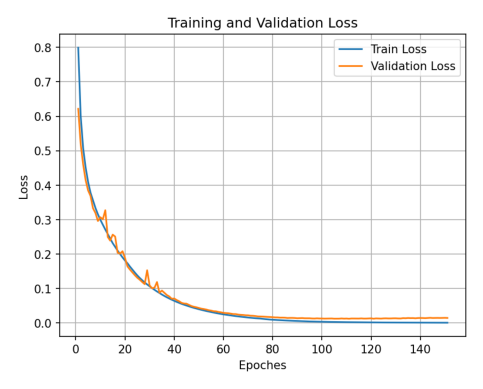

In [12]:
# Check training performance
img = np.array(Image.open('/home/tnguye47/Data/physionet.org/files/ct-ich/material/loss_curve.png'))
plt.imshow(img, cmap='gray')  # cmap='gray' for CT scans
plt.axis('off')  # hide axis numbers
plt.show()

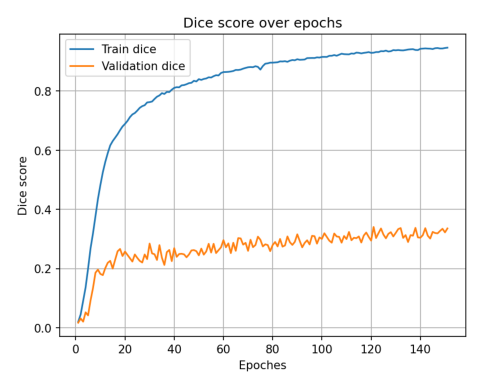

In [13]:
# Check training performance
img = np.array(Image.open('/home/tnguye47/Data/physionet.org/files/ct-ich/material/dice_pos_curse.png'))
plt.imshow(img, cmap='gray')  # cmap='gray' for CT scans
plt.axis('off')  # hide axis numbers
plt.show()

In [14]:
ct_scans_dir = Path("/home/tnguye47/Data/physionet.org/files/ct-ich/material/data/image")
masks_dir = Path("/home/tnguye47/Data/physionet.org/files/ct-ich/material/data/label")

In [15]:
# Read test data
test_df = pd.read_csv('./data/test_split.csv')

In [16]:

print(f"Test slices: {len(test_df)}")
print(f"Positive test slices: {test_df[test_df['No_Hemorrhage'] == 0].shape[0]}")

Test slices: 298
Positive test slices: 35


In [17]:
val_df = pd.read_csv('./data/val_split.csv')
print(f"Val slices: {len(val_df)}")
print(f"Positive val slices: {val_df[val_df['No_Hemorrhage'] == 0].shape[0]}")

Val slices: 818
Positive val slices: 88


In [18]:
# Read input and labels for test set
X_test = []
y_test = []
for _, row in test_df.iterrows():
    patient_no = int(row['PatientNumber'])
    slice_no   = int(row['SliceNumber'])

    # Load using patient + slice number
    ct_slice   = np.array(Image.open(ct_scans_dir / f"{patient_no}_{slice_no}.png"))
    mask_slice = np.array(Image.open(masks_dir  / f"{patient_no}_{slice_no}.png"))

    # Convert mask back to 0/1
    mask_slice = (mask_slice / 255).astype(np.uint8)

    # Add original
    ct_slice_expanded = np.expand_dims(ct_slice, axis=0)  # (1, 512, 512)
    X_test.append(ct_slice_expanded)
    
    mask_slice_expanded = np.expand_dims(mask_slice, axis=0)  # (1, 512, 512)
    y_test.append(mask_slice_expanded)    
    
X_test = np.array(X_test)    
y_test = np.array(y_test)

In [19]:
# Initialize the same model architecture
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)

In [20]:

# Load the saved weights
model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cpu')))
# Turn on the evaluation mode to disable dropout and batch normalization
model.eval()
print("Model loaded successfully!")

/scratch/local/ipykernel_93243/3968450584.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('c

Model loaded successfully!


In [21]:
# Perform the testing
def perform_testing(X_test, y_test, model, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Convert to tensors if needed
    if not isinstance(X_test, torch.Tensor):
        X_test = torch.from_numpy(X_test).float()
    if not isinstance(y_test, torch.Tensor):
        y_test = torch.from_numpy(y_test).long()

    # Create dataloader
    test_dataset = TensorDataset(X_test, y_test)
    # shuffle=False: We want to keep the order of input
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    dice = 0.0
    truePos = 0.0
    actualPos = 0.0
    dice_scores = []
    hemorrhage_dice = []    # (original_index, score) for positive slices
    global_idx = 0          # tracks original slice index across batches
    pred_binary = []
    with torch.no_grad():
        for images, masks in test_dataloader:
            images, masks = images.to(device), masks.to(device)
            pred_test = model(images)
            pred_test_prob = torch.sigmoid(pred_test)

            # Compute Dice score for each image
            # turn pred_test_prob into label for computing Dice score
            predict_label = (pred_test_prob > 0.5).float() # threshold at 0.5 -> 0,1
            
            for i in range(images.shape[0]):
                # multiply element-wise, count overlapping 1s
                intersection = (predict_label[i] * masks[i]).sum()
                # predict_label.sum(): sum number of 1s in this matrix
                
                pred_binary.append(predict_label[i].cpu().numpy())
                if masks[i].sum() > 0:
                    score = ((2 * intersection) / 
                             (predict_label[i].sum() + masks[i].sum() + 1e-8)).item()
                    dice_scores.append(score)
                    hemorrhage_dice.append((global_idx, score))  # store original index
                
  
                global_idx += 1  # increment for every slice, not just positive ones

                # Compute true positive for all images
                truePos += intersection
                actualPos += masks[i].sum()

        avg_dice = np.array(dice_scores).mean()
        sensitivity = truePos/actualPos
        # convert to numpy array
        pred_binary = np.array(pred_binary)  
        
    print(f"Dice score is {avg_dice} and sensitivity is {sensitivity}")
    return dice_scores, hemorrhage_dice, pred_binary


In [22]:
# handle testing for U-Net model
X_test_nor = X_test.astype(np.float32) / 255.0
# hemorrhage_dice = [(2, 0.71), (5, 0.45), (8, 0.83), ...]  # 60 items
dice_scores, hemorrhage_dice, pred_binary = perform_testing(X_test_nor, y_test, model, batch_size=16)

Dice score is 0.3205473210130419 and sensitivity is 0.3191194236278534


In [23]:
# creates a 1D numpy array filled entirely with NaN values, 
# with length equal to the number of test slices.
dice_lookup = np.full(len(y_test), np.nan)
for orig_idx, score in hemorrhage_dice:
    # Result — only positions 2, 5, 8... get filled
    # [nan, nan, 0.71, nan, nan, 0.45, nan, nan, 0.83, nan, ...]
    dice_lookup[orig_idx] = score

# Step 3: Sort for best/worst visualization
# The sort ascending by the second element x[1] which is the Dice score
hemorrhage_dice.sort(key=lambda x: x[1])
print("dice_scores ", len(dice_scores))
print("hemorrhage_dice ", len(hemorrhage_dice))

dice_scores  35
hemorrhage_dice  35


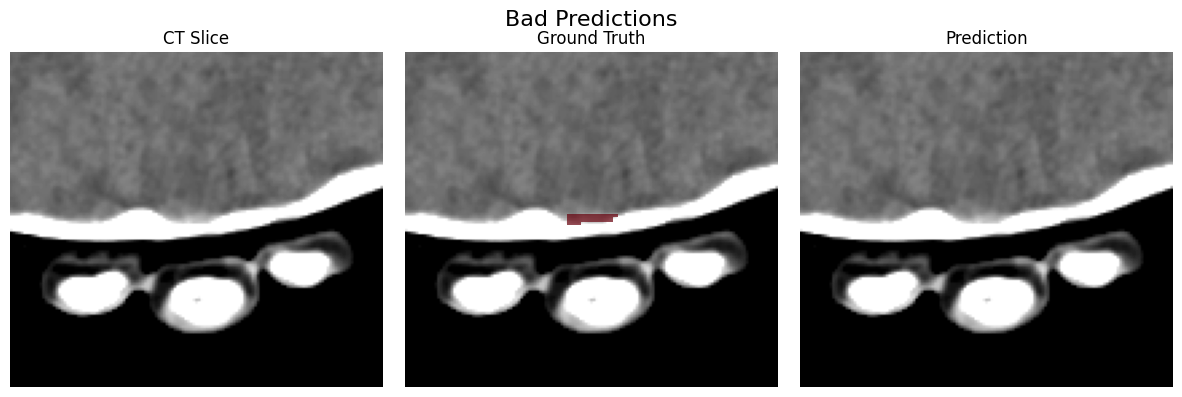

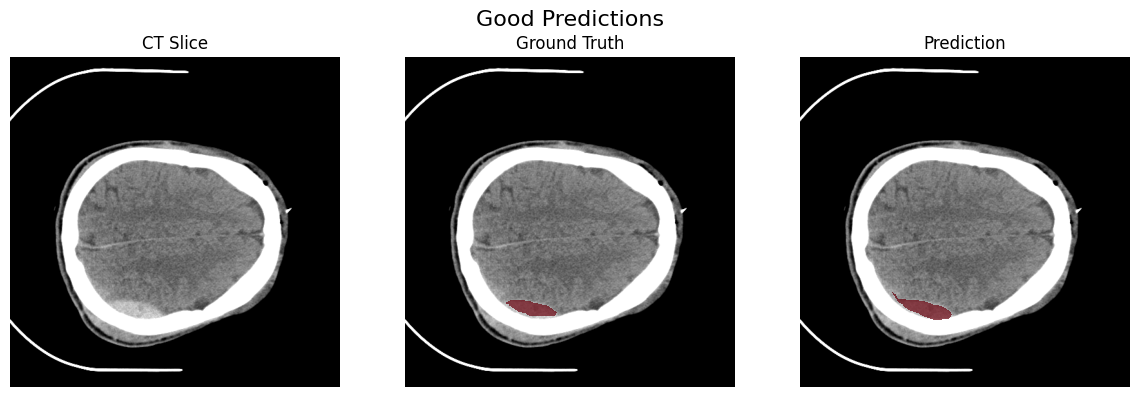

In [24]:
num_each = 1

# Get indices of best and worst predictions
# only among slices that have hemorrhage
# hemorrhage_idx = [i for i in range(len(y_test)) if y_test[i].max() > 0]

# hemorrhage_dice is a list of tuples like: [(5, 0.82), (12, 0.15), (3, 0.91), (7, 0.03)]
# hemorrhage_dice = [(i, dice_scores[i]) for i in hemorrhage_idx]

# sort by the second element of each tuple
# After sorting: [(7, 0.03), (12, 0.15), (5, 0.82), (3, 0.91)]
# hemorrhage_dice.sort(key=lambda x: x[1])

# for example
# worst_idx = [12, 5]   # num_each = 2
# best_idx  = [2, 8]
worst_idx = [x[0] for x in hemorrhage_dice[:num_each]]   # num_each lowest dice at the start
best_idx  = [x[0] for x in hemorrhage_dice[-num_each:]]  # num_each highest dice at the end    

# worst_i = worst_idx[0]  # the bad prediction slice index
# print(f"mask sum: {y_test[worst_i, 0].sum()}")
# print(f"pred sum: {pred_binary[worst_i, 0].sum()}")
# print(f"Dice score: {dice_lookup[worst_i]:.4f}")

# Plot
# runs the plotting code twice — once for worst, once for best. Each time title and indices change
for title, indices in [('Bad Predictions', worst_idx), ('Good Predictions', best_idx)]:
    fig, axes = plt.subplots(num_each, 3, figsize=(12, num_each * 4), squeeze=False)
    fig.suptitle(title, fontsize=16)
    axes[0, 0].set_title('CT Slice')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 2].set_title('Prediction')

    # row=0, i=12   # first row, slice 12
    # row=1, i=5    # second row, slice 5    
    for row, i in enumerate(indices):
        # X_test[12, 0] → shape (512, 512)
        ct   = X_test[i, 0]
        mask = y_test[i, 0]
        pred = pred_binary[i, 0]
        
        if mask.sum() < 100:
            # Find the bounding box of the hemorrhage
            mask_2d = mask
            rows = np.any(mask_2d > 0, axis=1)
            cols = np.any(mask_2d > 0, axis=0)
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]

            # Add padding around the region
            pad = 60
            rmin = max(0, rmin - pad)
            rmax = min(512, rmax + pad)
            cmin = max(0, cmin - pad)
            cmax = min(512, cmax + pad)

            # Crop all three images to that region
            ct   = X_test[i, 0][rmin:rmax, cmin:cmax]
            mask = y_test[i, 0][rmin:rmax, cmin:cmax]
            pred = pred_binary[i, 0][rmin:rmax, cmin:cmax]
            
        
        # Column 0: CT scan only
        axes[row, 0].imshow(ct, cmap='gray')
        # Column 1: CT scan + ground truth mask overlaid in red
        # axes[row, 1].imshow(mask, cmap='gray')
        axes[row, 1].imshow(ct, cmap='gray')
        # np.ma.masked_where: create a boolean array with True (mask==0)/False values
        # and then mark as transparent wherever True
        axes[row, 1].imshow(np.ma.masked_where(mask == 0, mask), 
                    cmap='Reds',   # bright red/yellow, more visible
                    alpha=0.7,       # more opaque
                    vmin=0, vmax=0.5)  # force full color range)
        
        # Column 2: CT scan + prediction overlaid in red
        axes[row, 2].imshow(ct, cmap='gray')
        axes[row, 2].imshow(np.ma.masked_where(pred == 0, pred), 
                    cmap='Reds',   # bright red/yellow, more visible
                    alpha=0.7,       # more opaque
                    vmin=0, vmax=0.5)  # force full color range)
    
        axes[row, 2].set_xlabel(f'Dice: {dice_lookup[i]:.2f}')
        
        # turns off the axis lines, ticks, and labels for all 3 plots in a row
        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    # plt.close()    
    plt.show()